#### Question 1
There are 5 jurors in a courtroom. Each of them can correctly identify the guilt of the defendant with 70% probability, independent of one another. What is the probability that the jurors will jointly reach the correct verdict if the final decision is by majority vote?

70.00%

83.20%

**83.70%**

87.50%


> We need at least 3 out of the 5 jurors to correctly identify the guilt. The probability of exactly $k$ jurors making the correct decision is given by the binomial formula: 
> 
> $$P(X=k) = \binom{n}{k} p^k (1-p)^{n-k}$$
> $$\mu = \sum{P(X)}$$
> 
> We need to calculate $P(X \ge 3)$, which is the sum of the probabilities of exactly 3, 4, or 5 jurors being correct:
> 
> * **Exactly 3 correct:** $\binom{5}{3} (0.7)^3 (0.3)^2 = 10 \times 0.343 \times 0.09 = 0.3087$
> * **Exactly 4 correct:** $\binom{5}{4} (0.7)^4 (0.3)^1 = 5 \times 0.2401 \times 0.3 = 0.36015$
> * **Exactly 5 correct:** $\binom{5}{5} (0.7)^5 (0.3)^0 = 1 \times 0.16807 \times 1 = 0.16807$
>
> $$ \mu = \sum_{i=3}^{5} \binom{5}{i} 0.7^i (1 - 0.7)^{5-i} = 83.70\% $$
> 
> Adding these probabilities together gives the total probability of a correct majority vote: 
> 
> $$P(X \ge 3) = 0.3087 + 0.36015 + 0.16807 = 0.83692$$

In [1]:
# Disable warnings in Anaconda
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

In [2]:
from matplotlib import rcParams

rcParams["figure.figsize"] = 11, 8

In [3]:
def fill_nan(table):
    for col in table.columns:
        table[col] = table[col].fillna(table[col].median())
    return table

In [4]:
# for Jupyter-book, we copy data from GitHub, locally, to save Internet traffic,
# you can specify the data/ folder from the root of your cloned
# https://github.com/Yorko/mlcourse.ai repo, to save Internet traffic
DATA_PATH = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/"

In [5]:
data = pd.read_csv(DATA_PATH + "credit_scoring_sample.csv", sep=";")
data.head()

,SeriousDlqin2yrs,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,NumberOfTimes90DaysLate,NumberOfTime60-89DaysPastDueNotWorse,MonthlyIncome,NumberOfDependents
0,0,64,0,0.249908,0,0,8158.0,0.0
1,0,58,0,3870.000000,0,0,NaN,0.0
2,0,41,0,0.456127,0,0,6666.0,0.0
3,0,43,0,0.000190,0,0,10500.0,2.0
4,1,49,0,0.271820,0,0,400.0,0.0


In [6]:
data.dtypes

SeriousDlqin2yrs                          int64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
NumberOfTimes90DaysLate                   int64
NumberOfTime60-89DaysPastDueNotWorse      int64
MonthlyIncome                           float64
NumberOfDependents                      float64
dtype: object

Distribution of the target:


SeriousDlqin2yrs
0    0.777511
1    0.222489
Name: count, dtype: float64

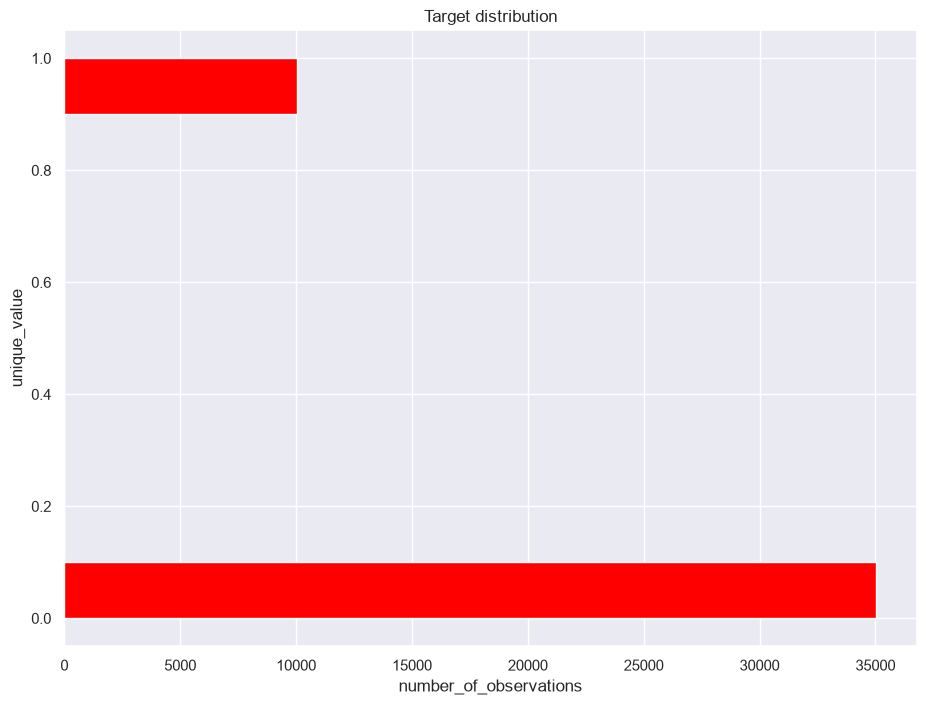

In [7]:
ax = data["SeriousDlqin2yrs"].hist(orientation="horizontal", color="red")
ax.set_xlabel("number_of_observations")
ax.set_ylabel("unique_value")
ax.set_title("Target distribution")

print("Distribution of the target:")
data["SeriousDlqin2yrs"].value_counts() / data.shape[0]

In [8]:
independent_columns_names = [x for x in data if x != "SeriousDlqin2yrs"]
independent_columns_names

['age',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'DebtRatio',
 'NumberOfTimes90DaysLate',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'MonthlyIncome',
 'NumberOfDependents']

In [9]:
table = fill_nan(data)

In [10]:
# separation of columns for train data
X = table[independent_columns_names]
y = table["SeriousDlqin2yrs"]

## Bootstrapping
#### Question 2
Make an interval estimate of the average age for the customers who delayed repayment at the 90% confidence level. Use the example from the article as reference, if needed. Also, use np.random.seed(0) as before. What is the resulting interval estimate?

1. 52.59 – 52.86
2. 45.71 – 46.13
3. 45.68 – 46.17
4. 52.56 – 52.88



In [11]:
def get_bootstrap_samples(data, n_samples):
    """Generate samples using bootsptrapping."""
    indices = np.random.randint(0, len(data), (n_samples, len(data)))
    samples = data[indices]
    return samples

def stat_intervals(stat, alpha):
    """Make an interval estimate."""
    boundaries = np.percentile(stat, [100*alpha/2.0, 100*(1-alpha/2.0)])
    return boundaries

# Save the ages of those who let a delay
churn = data[data["SeriousDlqin2yrs"] == 1]["age"].values

# Set the random seed for reproducibility
np.random.seed(0)

# Generate bootstrap samples and calculate the mean for each sample
churn_mean_scores = [np.mean(sample) for sample in get_bootstrap_samples(churn, 1000)]

# Print the interval estimate for the sample means
print("Mean interval", stat_intervals(churn_mean_scores, 0.1))

Mean interval [45.71379414 46.12700479]


## Logistic regression

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [13]:
lr = LogisticRegression(random_state=5, class_weight="balanced")

In [14]:
parameters = {"C": (0.0001, 0.001, 0.01, 0.1, 1, 10)}

In [15]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)

#### Question 3
Perform a Grid Search with the scoring metric “roc_auc” for the parameter C. Which value of the parameter C is optimal?

1. 0.0001
2. 0.001
3. 0.01
4. 0.1
5. 1
6. 10

In [16]:
grid_search = GridSearchCV(lr, parameters, n_jobs=-1, scoring='roc_auc', cv=skf)
grid_search = grid_search.fit(X, y)
grid_search.best_estimator_

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",10
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",5
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default s

#### Question 4
Can we consider the best model stable? The model is stable if the standard deviation on validation is less than 0.5%. Save the ROC AUC value of the best model, it will be useful for the following tasks.

In [17]:
grid_search.cv_results_['std_test_score']

array([0.00524592, 0.00513111, 0.0033523 , 0.00576127, 0.00436284,
       0.00711269])

In [18]:
grid_search.best_score_

np.float64(0.7947349973937554)

# Feature importance
#### Question 5
Feature importance is defined by the absolute value of its corresponding coefficient. First you need to normalize all the feature values so that it will be correct to compare them. What is the most important feature for the best logistic regression model?

1. age
2. NumberOfTime30-59DaysPastDueNotWorse
3. DebtRatio
4. NumberOfTimes90DaysLate
5. NumberOfTime60-89DaysPastDueNotWorse
6. MonthlyIncome
7. NumberOfDependents

In [19]:
from sklearn.preprocessing import StandardScaler

lr = LogisticRegression(C=0.001, random_state=5, class_weight='balanced', max_iter=5000)
scal = StandardScaler()
lr.fit(scal.fit_transform(X), y)

pd.DataFrame({'feat': independent_columns_names, 'coef': lr.coef_.flatten().tolist()}).sort_values(by='coef', ascending=False)

,feat,coef
1,NumberOfTime30-59DaysPastDueNotWorse,0.723421
3,NumberOfTimes90DaysLate,0.516656
4,NumberOfTime60-89DaysPastDueNotWorse,0.195486
6,NumberOfDependents,0.101722
2,DebtRatio,-0.024068
5,MonthlyIncome,-0.163015
0,age,-0.417115


#### Question 6
Calculate how much DebtRatio affects the prediction using the softmax function. What is its value?

1. 0.38
2. -0.02
3. 0.11
4. 0.24

In [21]:
print((np.exp(lr.coef_[0]) / np.sum(np.exp(lr.coef_[0]))))

[0.0771092  0.24123207 0.11423642 0.19617236 0.14228387 0.09941701
 0.12954907]


#### Question 7
Let’s see how we can interpret the impact of our features. For this, recalculate the logistic regression with absolute values, that is without scaling. Next, modify the customer’s age by adding 20 years, keeping the other features unchanged. How many times will the chance that the customer will not repay their debt increase? You can find an example of the theoretical calculation here.

1. -0.01
2. 0.70
3. 8.32
4. 0.66

In [22]:
lr = LogisticRegression(C=0.001, random_state=5, class_weight='balanced', max_iter=5000)
lr.fit(X, y)

pd.DataFrame({'feat': independent_columns_names, 'coef': lr.coef_.flatten().tolist()}).sort_values(by='coef', ascending=False)

,feat,coef
1,NumberOfTime30-59DaysPastDueNotWorse,0.468346
3,NumberOfTimes90DaysLate,0.403954
6,NumberOfDependents,0.072011
4,NumberOfTime60-89DaysPastDueNotWorse,0.051189
2,DebtRatio,-0.000017
5,MonthlyIncome,-0.000018
0,age,-0.029959


In [ ]:
np.exp(lr.coef_[0][0] * 20)

np.float64(0.549257608096361)

# Random Forest

In [26]:
from sklearn.ensemble import RandomForestClassifier

In [27]:
rf = RandomForestClassifier(
    n_estimators=100, n_jobs=-1, random_state=42, class_weight="balanced"
)

In [28]:
parameters = {
    "max_features": [1, 2, 4],
    "min_samples_leaf": [3, 5, 7, 9],
    "max_depth": [5, 10, 15],
}

#### Question 8
How much higher is the ROC AUC of the best random forest model than that of the best logistic regression on validation? Select the closest answer.

1. 0.04
2. 0.03
3. 0.02
4. 0.01

In [30]:
%%time
rf_grid_search = GridSearchCV(rf, parameters, n_jobs=-1, scoring='roc_auc', cv=skf, verbose=True)
rf_grid_search = rf_grid_search.fit(X, y)

print(rf_grid_search.best_score_ - grid_search.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


/Users/samuelbagin/Desktop/code/ml-course/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/samuelbagin/Desktop/code/ml-course/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/samuelbagin/Desktop/code/ml-course/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn

0.041090729310518714
CPU times: user 2.86 s, sys: 414 ms, total: 3.27 s
Wall time: 1min 3s


#### Question 9
What feature has the weakest impact in Random Forest model?

1. age
2. NumberOfTime30-59DaysPastDueNotWorse
3. DebtRatio
4. NumberOfTimes90DaysLate
5. NumberOfTime60-89DaysPastDueNotWorse
6. MonthlyIncome
7. NumberOfDependents

In [31]:
independent_columns_names[np.argmin(rf_grid_search.best_estimator_.feature_importances_)]

'NumberOfDependents'

In [34]:
pd.DataFrame(
    {'col': independent_columns_names, 'importance': rf_grid_search.best_estimator_.feature_importances_}
).sort_values(by='importance')

,col,importance
6,NumberOfDependents,0.013174
5,MonthlyIncome,0.055170
2,DebtRatio,0.073405
0,age,0.114879
4,NumberOfTime60-89DaysPastDueNotWorse,0.160411
3,NumberOfTimes90DaysLate,0.286487
1,NumberOfTime30-59DaysPastDueNotWorse,0.296475


#### Question 10
What is the most significant advantage of using Logistic Regression versus Random Forest for this problem?

1. Spent less time for model fitting;
2. Fewer variables to iterate;
3. Feature interpretability;
4. Linear properties of the algorithm.

**Answer: 3.**

> Solution:
>
> On the one hand, the Random Forest model works better for our credit scoring problem. Its performance is 4% higher. The reason for such a result is a small number of features and the compositional property of random forests.
>
> On the other hand, the main advantage of Logistic Regression is that we can interpret the feature impact on the model outcome.




# Bagging

In [35]:
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import RandomizedSearchCV, cross_val_score

parameters = {
    "max_features": [2, 3, 4],
    "max_samples": [0.5, 0.7, 0.9],
    "base_estimator__C": [0.0001, 0.001, 0.01, 1, 10, 100],
}

#### Question 11
Fit a bagging classifier with random_state=42. For the base classifiers, use 100 logistic regressors and use RandomizedSearchCV instead of GridSearchCV. It will take a lot of time to iterate over all 54 variants, so set the maximum number of iterations for RandomizedSearchCV to 20. Don’t forget to set the parameters cv and random_state=1. What is the best ROC AUC you achieve?

1. 80.75%
2. 80.12%
3. 79.62%
4. 76.50%



In [37]:
bg = BaggingClassifier(
    LogisticRegression(class_weight="balanced"),
    n_estimators=100,
    n_jobs=-1,
    random_state=42,
)
r_grid_search = RandomizedSearchCV(
    bg,
    parameters,
    n_jobs=-1,
    scoring="roc_auc",
    cv=skf,
    n_iter=20,
    random_state=1,
    verbose=True,
)
r_grid_search = r_grid_search.fit(X, y)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


ValueError: Invalid parameter 'base_estimator' for estimator BaggingClassifier(estimator=LogisticRegression(class_weight='balanced'),
                  max_features=2, max_samples=0.9, n_estimators=100, n_jobs=-1,
                  random_state=42). Valid parameters are: ['bootstrap', 'bootstrap_features', 'estimator', 'max_features', 'max_samples', 'n_estimators', 'n_jobs', 'oob_score', 'random_state', 'verbose', 'warm_start'].